# Fire analysis


In [1]:
DB_FILE = "fire.duckdb"
STATE = "OR"

## DuckDB / SQL Magic setup

Using [JupySQL](https://jupysql.readthedocs.io/). [Docs from DuckDB.](https://duckdb.org/docs/current/guides/python/jupyter)


In [2]:
%config SqlMagic.autopandas = True
%config SqlMagic.displaycon = False

In [3]:
import duckdb

%load_ext sql
conn = duckdb.connect(DB_FILE)
%sql conn --alias duckdb

Tip: You may define configurations in /Users/afeld/dev/ptps-wildfire-demo/pyproject.toml or /Users/afeld/.jupysql/config.

Did not find user configurations in /Users/afeld/dev/ptps-wildfire-demo/pyproject.toml.

In [4]:
from helpers import run_script_in_db


run_script_in_db(conn, "setup.sql")
run_script_in_db(conn, "views.sql")

In [5]:
import pandas as pd

pd.set_option("display.max_columns", 100)

## Burn probabilities


https://jupysql.readthedocs.io/en/docs/plot.html#histogram


Text(0.5, 1.0, 'Burn probability distribution')

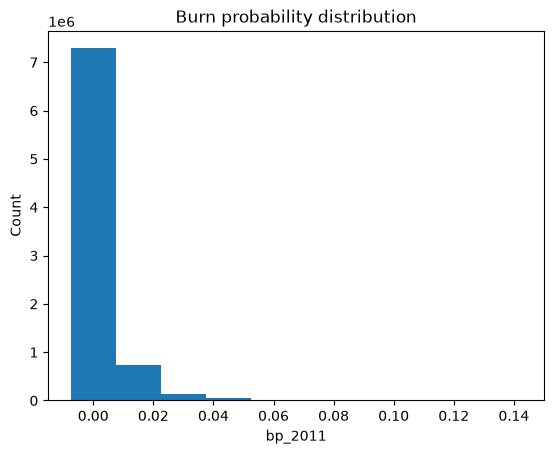

In [6]:
ax = %sqlplot histogram --table burn_prob_1km --column bp_2011 --bins 10
ax.set_title("Burn probability distribution")


In [7]:
from lonboard import Map, ScatterplotLayer

from helpers import to_continuous_color_map

PROBABILITY_PERCENTILE = 0.95

query = f"""
SELECT
    point,
    bp_2011
FROM burn_prob_1km
WHERE bp_2011 > (
    SELECT percentile_cont({PROBABILITY_PERCENTILE}) WITHIN GROUP (ORDER BY bp_2011) AS cutoff
    FROM burn_prob_1km
);
"""

values = conn.execute(query).df()["bp_2011"]
colors = to_continuous_color_map(values, "OrRd")

layer = ScatterplotLayer.from_duckdb(
    query,
    conn,
    crs="EPSG:4326",
    get_fill_color=colors,
    radius_min_pixels=2,
    radius_scale=500,
    radius_units="meters",
)
m = Map(layer)
m

## State-level


In [8]:
%%sql
SELECT COUNT(*)
FROM burn_prob_1km AS bp
INNER JOIN state_boundaries AS state
    ON ST_Contains(state.geom, bp.point)
WHERE state.stusps = '{{STATE}}';

,count_star()
0,272935


In [9]:
query = f"""
SELECT
    bp.point,
    bp.bp_2011
FROM burn_prob_1km AS bp
INNER JOIN state_boundaries AS state
    ON ST_Contains(state.geom, bp.point)
WHERE state.stusps = '{STATE}'
"""

values = conn.execute(query).df()["bp_2011"]
# match color scheme for Wildfire Hazard Potential to compare
# https://experience.arcgis.com/experience/78e7e78bcef64dfc98cf13e2e0eae156
colors = to_continuous_color_map(values, "RdYlGn_r")

layer = ScatterplotLayer.from_duckdb(
    query,
    conn,
    crs="EPSG:4326",
    get_fill_color=colors,
    radius_min_pixels=2,
    radius_scale=500,
    radius_units="meters",
)
m = Map(layer)
m

## Red flag warnings


In [10]:
from lonboard import PolygonLayer

layer = PolygonLayer.from_duckdb(
    "SELECT * FROM red_flag_warnings",
    conn,
    crs="EPSG:4326",
    get_fill_color=[255, 0, 0],
)
m = Map(layer)
m

## Active fires


### Query data

> Each MODIS active fire/thermal hotspot location represents the center of a 1km pixel that is flagged by the algorithm as containing one or more fires within the pixel.

https://www.earthdata.nasa.gov/data/tools/firms

https://firms.modaps.eosdis.nasa.gov/active_fire/#firms-txt


In [11]:
%%sql
SELECT *
FROM active_fires
LIMIT 10;


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,confidence,version,bright_t31,frp,daynight
0,45.29657,-69.49461,326.35,1.42,1.18,2026-08-09,0026,T,100,6.1NRT,286.45,41.08,N
1,18.31891,-88.33073,316.88,2.35,1.48,2026-08-09,0158,T,92,6.1NRT,293.69,42.97,N
2,18.31735,-88.33570,314.31,2.35,1.48,2026-08-09,0158,T,88,6.1NRT,293.83,36.78,N
3,20.72093,-76.02602,306.44,1.95,1.36,2026-08-09,0158,T,45,6.1NRT,290.02,14.14,N
4,19.39528,-92.03804,306.85,4.28,1.91,2026-08-09,0158,T,49,6.1NRT,292.19,36.88,N
5,19.40042,-92.04571,305.32,4.28,1.91,2026-08-09,0158,T,27,6.1NRT,292.26,30.11,N
6,20.54469,-87.33319,314.37,1.78,1.31,2026-08-09,0158,T,89,6.1NRT,292.90,25.21,N
7,21.53366,-87.03705,305.53,1.62,1.25,2026-08-09,0158,T,54,6.1NRT,294.12,8.01,N
8,21.54455,-87.03920,328.75,1.62,1.25,2026-08-09,0158,T,100,6.1NRT,294.33,49.83,N
9,41.45987,-81.67714,302.94,1.55,1.23,2026-08-09,0204,T,52,6.1NRT,290.15,11.42,N
